# Sprint 4: Machine learning power prediction

**Plan**
- Phase 1: Single turbine benchmark
    - Feature selection
    - Cleaning
    - Train/Test split
    - Linear Regression
    - Random Forest
    - Gradient Boosting
    - Metrics
    - Plots
    - Discussion
- Phase 2: Wake-affected wind turbine comparison
    - Repeat the same pipeline for turbine like C2, D2
    - Compare upstream turbine vs downstream
    - Clean inflow vs wake distrubed one
    - Model robustness under more complex physics
- Phase 3: Wind-farm scale extension
    - Option 1: Build one model per wind turbine
    - Option 2: Build generelized model across many turbines
    - Option 3: Predict total power park


## Objective

The goal of this analysis is to build machine learning models capable of predicting wind turbine power output using SCADA data.

Unlike the previous project phase, which focused on wake analysis, this step focuses on **predictive modelling**.

We compare several regression models of increasing complexity:

- Linear Regression
- Random Forest
- Gradient Boosting

The objective is to evaluate how well these models can capture the relationship between turbine power production and environmental/operational variables.

Model performance will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

---



# 1. Single Wind Turbine

For the first model we focus on **turbine A2**.

Reasons:

- Turbine A2 has a complete SCADA signal set including power output.
- It is located relatively upstream in the wind farm layout.
- Upstream turbines experience less wake influence from other turbines, making them a good baseline for modelling turbine power behaviour.

Later extensions of the project will include wake-affected downstream turbines.

In [59]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
ds = xr.open_dataset('../data/norre_m2_all.nc')

print(ds.head(10))

<xarray.Dataset> Size: 21kB
Dimensions:     (time: 10)
Coordinates:
  * time        (time) datetime64[ns] 80B 1991-12-22T23:36:00 ... 1991-12-23T...
Data variables: (12/260)
    connect     (time) float64 80B ...
    connect_qc  (time) int16 20B ...
    d31_1       (time) float64 80B ...
    d31_1_qc    (time) float64 80B ...
    d34_2       (time) float64 80B ...
    d34_2_qc    (time) float64 80B ...
    ...          ...
    f7_pow      (time) float64 80B ...
    f7_pow_qc   (time) float64 80B ...
    f7_wsn      (time) float64 80B ...
    f7_wsn_qc   (time) float64 80B ...
    f7_ym       (time) float64 80B ...
    f7_ym_qc    (time) float64 80B ...
Attributes: (12/26)
    title:                   Wind farm data from Norrekaer Enge, DK
    authors:                 Kurt Schaldemose Hansen, Nikola Vasiljević and S...
    summary:                 This dataset includes SCADA data and mast measur...
    comment:                 
    history:                 2022-01-27T10:49:35\tUpdated m

## Extract relevant variables

We construct a dataframe containing the variables required for modelling turbine A2 power output.


In [60]:
df = pd.DataFrame({
    'power': ds['a2_pow'].values,
    'ws_nacelle': ds['a2_wsn'].values,
    'yaw_misalignment': ds['a2_ym'].values,
    'mast_ws1': ds['s31_1'].values,
    'mast_ws2': ds['s31_2'].values,
    'wind_dir1': ds['d31_1'].values,
    'wind_dir2': ds['d34_2'].values
})

df.head()

,power,ws_nacelle,yaw_misalignment,mast_ws1,mast_ws2,wind_dir1,wind_dir2
0,159.5,NaN,0.0,10.61,11.33,257.41,253.61
1,157.0,NaN,0.0,10.69,11.28,259.57,255.78
2,124.4,NaN,0.0,9.91,9.74,260.11,257.12
3,138.5,NaN,0.0,10.85,10.73,255.64,254.12
4,148.6,NaN,0.0,11.18,10.16,252.99,252.15


## Feature engineering

Two derived variables are created:

Average mast wind speed  
Average wind direction

This reduces noise from individual sensors.

Additionally, a **lagged power feature** is created using the previous timestep.

Including previous power helps capture temporal persistence in turbine behaviour.

In [61]:
# Average mast wind speed
df['mast_ws'] = (df['mast_ws1'] + df['mast_ws2']) / 2

# Average wind direction
df['mast_dir'] = (df['wind_dir1'] + df['wind_dir2']) / 2

# Previous power
df['prev_power'] = df['power'].shift(1)

df.head()

,power,ws_nacelle,yaw_misalignment,mast_ws1,mast_ws2,wind_dir1,wind_dir2,mast_ws,mast_dir,prev_power
0,159.5,NaN,0.0,10.61,11.33,257.41,253.61,10.970,255.510,NaN
1,157.0,NaN,0.0,10.69,11.28,259.57,255.78,10.985,257.675,159.5
2,124.4,NaN,0.0,9.91,9.74,260.11,257.12,9.825,258.615,157.0
3,138.5,NaN,0.0,10.85,10.73,255.64,254.12,10.790,254.880,124.4
4,148.6,NaN,0.0,11.18,10.16,252.99,252.15,10.670,252.570,138.5


## Data cleaning

Rows containing missing values are removed before training the machine learning models.

In [62]:
print('Total rows:', len(df))
print('\nMissing values per column:')
print(df.isna().sum())
df = df.dropna()

print("\nRows after cleaning:", len(df))

Total rows: 72577

Missing values per column:
power               48844
ws_nacelle          49563
yaw_misalignment    45965
mast_ws1            48195
mast_ws2            48195
wind_dir1           48195
wind_dir2           48195
mast_ws             48195
mast_dir            48195
prev_power          48844
dtype: int64

Rows after cleaning: 18206


## Power curve sanity check

Before training models we verify that turbine power behaves as expected relative to nacelle wind speed.

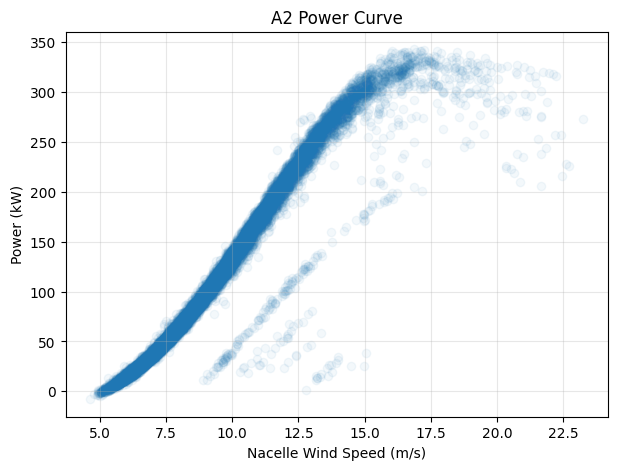

In [63]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["ws_nacelle"],
    df["power"],
    alpha=0.05
)

plt.xlabel("Nacelle Wind Speed (m/s)")
plt.ylabel("Power (kW)")
plt.title("A2 Power Curve")

plt.savefig("../figures/sprint4_a2_power_curve.png", dpi=300)
plt.grid(alpha=0.3)
plt.show()

**Obervations**
- Clean ramp-up region (5-12 m/s)
- Smooth transition toward rated
- Rated power ~340kW
- Slight scatter near plateau

Meaning:
- Nacelle wind speed is strong predictive feature
- Turbine behaves physically correct
- Cleaning step did not break the dataset

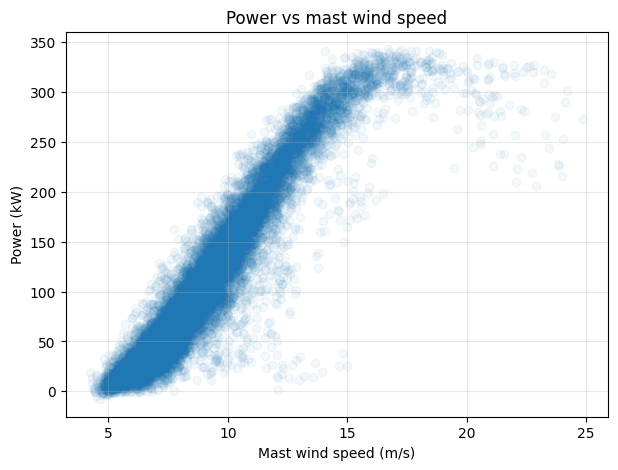

In [64]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["mast_ws"],
    df["power"],
    alpha=0.05
)

plt.xlabel("Mast wind speed (m/s)")
plt.ylabel("Power (kW)")
plt.title("Power vs mast wind speed")

plt.grid(alpha=0.3)
plt.savefig("../figures/sprint4_a2_power_vs_mast_wind_speed.png", dpi=300)
plt.show()

**Differences from previous plot**
- More scatter
- Weaker relationship
- More vertical spread

**Differences come from**
- Wake effects
- Turbulence
- Local inflow variations
- Turbine control dynamics


Instead of keeping both wind direction sensors seperately, we should wrap direction properly

Wind direction is circular (0=360), so ML models behave better if we convert it.


In [65]:
df['dir_sin'] = np.sin(np.deg2rad(df['mast_dir']))
df['dir_cos'] = np.cos(np.deg2rad(df['mast_dir']))



## Train-test split

Because SCADA data is a time series, the dataset is split chronologically.

The first 80% of the data is used for training and the remaining 20% is used for testing.

In [66]:
# Update feature list
features = [
    "ws_nacelle",
    "yaw_misalignment",
    "mast_ws",
    "dir_sin",
    "dir_cos",
    "prev_power"
]

X = df[features]
y = df['power']

# Chronological split
split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 14564
Testing samples: 3642


## Model 1 — Linear Regression

The first model used is a simple linear regression.

This model assumes that turbine power can be approximated as a linear combination of the input features.

Although turbine power curves are highly nonlinear, linear regression serves as a useful baseline model for comparison with more complex machine learning models.

Performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Initialize model
lin_model = LinearRegression()

# Train model
lin_model.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_model.predict(X_test)


### Evaluate model

In [68]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print('Linear Regression')
print('---------------------------')
print(f'MAE     :   {mae_lin:.2f} kW')
print(f'RMSE    :   {rmse_lin:.2f} kW')

Linear Regression
---------------------------
MAE     :   9.88 kW
RMSE    :   15.40 kW


Considering that rated power output is 335 kW, relative error is:
- MAE ~ 3%
- RMSE ~ 4-5%

Why it works well:
- Strong correlation between wind speed and power
- Inclusion of *prev_power*
- Clean usptream turbine (A2)
- Large dataset (~18k samples)

**So baseline model is already quite strong**

### Prediction vs measured plot

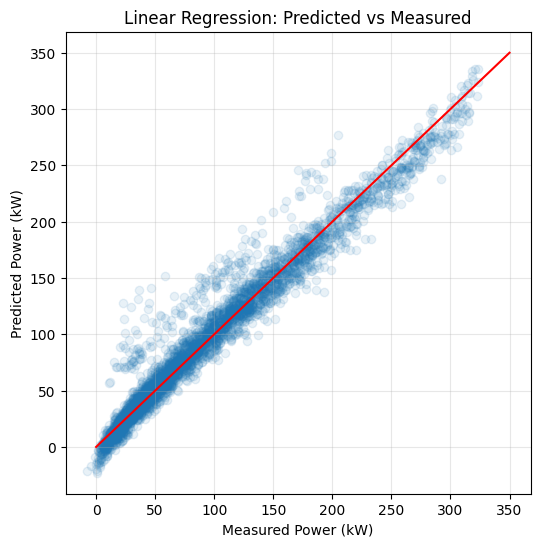

In [69]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_lin,
    alpha=0.1
)

plt.xlabel('Measured Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title('Linear Regression: Predicted vs Measured')

# Perfect prediction line
plt.plot([0,350],[0,350], color='red')

plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_lin_reg_pred_vs_meas.png", dpi=300)
plt.show()

Good signs:
- Majority of points close to the 1:1 line
- Clean diagonal trend
- No extreme bias

**That mean that model captures overall power curve behaviour**

Expected imprefections:
- Slight underprediction near rated power in upper region
- Small spread in mid-power region

### Time-series slice


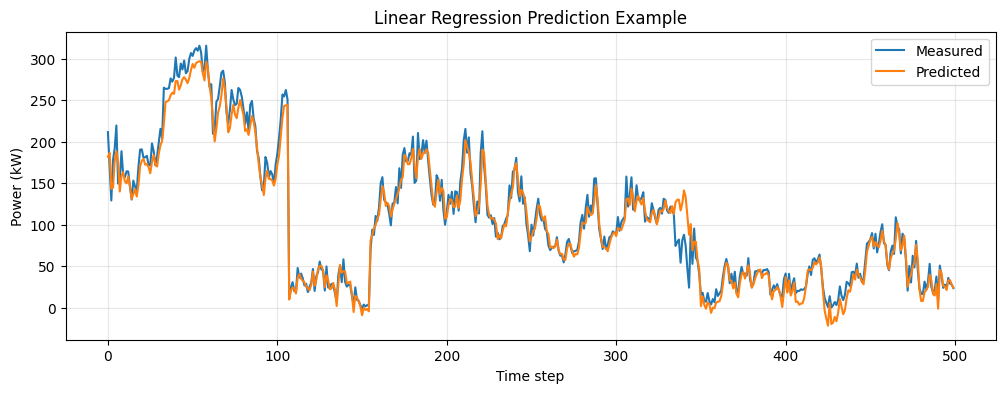

In [70]:
plt.figure(figsize=(12,4))

plt.plot(y_test.values[:500], label="Measured")
plt.plot(y_pred_lin[:500], label="Predicted")

plt.xlabel("Time step")
plt.ylabel("Power (kW)")
plt.title("Linear Regression Prediction Example")

plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../figures/sprint4_lin_reg_prediction_example.png", dpi=300)
plt.show()

- Predicted power curve follows measured curve closely
- Model captures temporal changes well
- No large lag or instability

**One interesting thing visible**

In the first 100 timesteps, model slightly underpredicts peaks, again reflecting region non-linearity.

Gradient boosting will likely fix it.

### Summary 
The linear regression model provides a strong baseline for turbine power prediction, achieving an MAE of 9.9 kW and an RMSE of 15.4 kW.

The model captures the overall relationship between wind speed and power output, as shown by the strong alignment along the 1:1 line in the prediction scatter plot.

However, deviations appear in the higher power region near rated power, where turbine control dynamics introduce nonlinear behaviour that cannot be fully captured by a linear model.

## Model 2 — Random Forest

Random Forest is an ensemble learning method based on decision trees.

Unlike linear regression, Random Forest can capture nonlinear relationships between the input features and turbine power output.

This makes it particularly suitable for modelling wind turbine power curves, which exhibit nonlinear behaviour.

Advantages:
- Captures nonlinear relationship
- Robust to noise
- Handles interactions between variables

In [71]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

**Evaluate**

In [72]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test,y_pred_rf))

print('Random Forest Performance')
print('---------------------------')
print(f'MAE:{mae_rf:.2f} kW')
print(f'RMSE:{rmse_rf:.2f} kW')

Random Forest Performance
---------------------------
MAE:7.77 kW
RMSE:18.73 kW


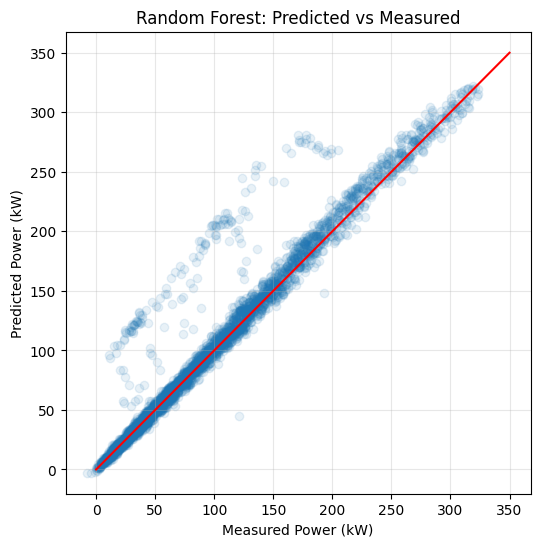

In [73]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.1
)

plt.xlabel('Measured Power (kW)')
plt.ylabel('Predicted Power (kW)')
plt.title('Random Forest: Predicted vs Measured')

# Perfect prediction line
plt.plot([0,350],[0,350], color='red')

plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_rf_pred_vs_meas.png", dpi=300)
plt.show()

## Comparison of results Linear Regression vs Random Forest

| Model             | MAE      | RMSE        |
| ----------------- | -------- | ----------- |
| Linear Regression | 9.88     | 15.40       |
| Random Forest     | **7.77** | **18.73** ❗ |

At first glance, we might expect that Random Forest should beat Linear Regression across the board, but that's not what happened.

- MAE improved
- RMSE got worse -> large error somwhere

**What this means**
- RMSE penelizes large errors strongly
- Reason 1: Noisy region (rated transitions)
    - From power curve around 12-16 m/s
    - Data is noisy
    - Turbine control is unstable
    - Random forest tends to overfit local patterns. Creating outliers which increase RMSE
- Reason 2: Previous power feature
    - Linear regression used it smoothly
    - Random forest may overlay on it in some branches. So if previous values is misleading -> prediction jumps
- Reason 3: Tree models are piecewise
    - Random forest builds step-;ike approximations
    - That can introduce small regions with wrong predictions

Scatter plot confirms this:
- Most points tightly around diagonal line which is good
- But some points are far away from line, those few points increase RMSE

**Conclusion**
The Random Forest model improves the mean absolute error compared to linear regression, indicating better average predictive performance.

However, the RMSE increases, suggesting that the model produces larger errors for certain observations.

This behavior is likely due to the model capturing local nonlinear patterns and noise in the data, particularly in regions where turbine control introduces variability, such as near rated power.

## Model 3 — Gradient Boosting

Gradient Boosting is an ensemble learning method that builds models sequentially, where each new model attempts to correct the errors of the previous ones.

Compared to Random Forest, Gradient Boosting typically provides:

- better accuracy
- improved handling of complex nonlinear relationships
- reduced large prediction errors

This makes it particularly suitable for modelling wind turbine power output, especially in regions with nonlinear behaviour such as the transition to rated power.

**Train model**

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

**Evaluate**

In [75]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print('Gradient Boosting Performance')
print('-------------------------------')
print(f'MAE: {mae_gb:.2f} kW')
print(f'RMSE: {rmse_gb:.2f} kW')

Gradient Boosting Performance
-------------------------------
MAE: 7.48 kW
RMSE: 17.57 kW


**Scatter plots**

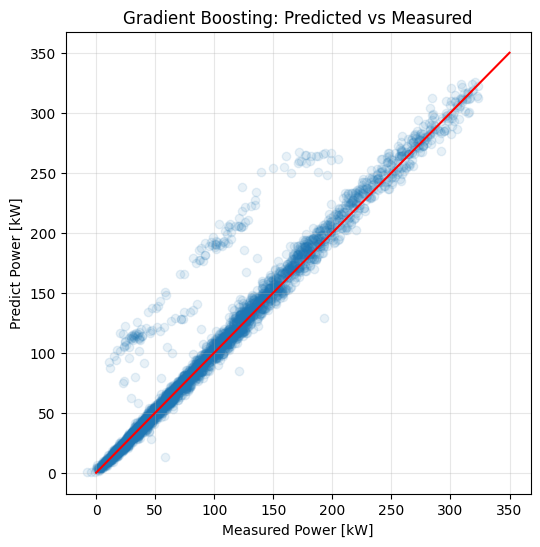

In [76]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.1
)

plt.xlabel('Measured Power [kW]')
plt.ylabel('Predict Power [kW]')
plt.title('Gradient Boosting: Predicted vs Measured')

plt.plot([0,350], [0,350], color='red')

plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_gb_pred_vs_meas.png", dpi=300)
plt.show()

The comparison of machine learning models reveals that model complexity does not necessarily guarantee improved performance across all metrics.

Gradient Boosting achieved the lowest MAE, indicating the best average predictive accuracy. However, Linear Regression achieved the lowest RMSE, suggesting more stable predictions with fewer large errors.

Tree-based models (Random Forest and Gradient Boosting) were better at capturing nonlinear relationships in the data but introduced larger prediction errors in certain regions, particularly near rated power where turbine control behavior becomes more complex.

This highlights a trade-off between accuracy and robustness:
- Linear models provide stable, smooth predictions
- Nonlinear models improve average accuracy but may overfit noisy regions

For wind turbine SCADA data, both approaches provide value depending on the application.

## Error vs Wind speed plot comparison


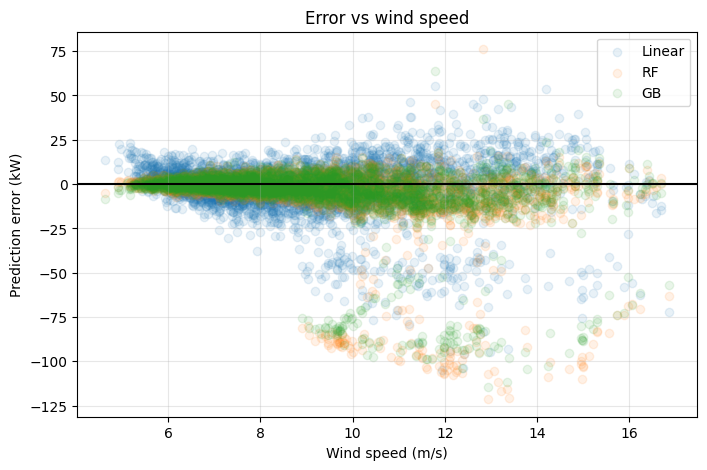

In [77]:
errors_lin = y_test - y_pred_lin
errors_rf = y_test - y_pred_rf
errors_gb = y_test - y_pred_gb

plt.figure(figsize=(8,5))

plt.scatter(X_test["ws_nacelle"], errors_lin, alpha=0.1, label="Linear")
plt.scatter(X_test["ws_nacelle"], errors_rf, alpha=0.1, label="RF")
plt.scatter(X_test["ws_nacelle"], errors_gb, alpha=0.1, label="GB")

plt.axhline(0, color='black')

plt.xlabel("Wind speed (m/s)")
plt.ylabel("Prediction error (kW)")
plt.title("Error vs wind speed")

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_models_error.png", dpi=300)
plt.show()

The largest prediction errors occur in the transition region (approximately 9–14 m/s), where turbine control mechanisms introduce nonlinear and highly variable behavior.

Tree-based models capture nonlinear relationships better but are more sensitive to local variability, resulting in larger prediction errors in this region.

# 2. Wake-affected turbine prediction (C2)

To investigate how wake effects influence machine learning performance, the same modelling pipeline is applied to **turbine C2**.

Compared to A2, turbine C2 is located further downstream in the wind farm and is therefore more exposed to wake interactions from upstream turbines.

This allows comparison between:

- **A2**: relatively upstream, cleaner inflow
- **C2**: downstream, wake-affected inflow

The same feature engineering and model settings are used to ensure a fair comparison.

Total rows before cleaning: 72577

Missing values per column:
power               48008
ws_nacelle          49030
yaw_misalignment    45120
mast_ws             48195
dir_sin             48195
dir_cos             48195
prev_power          48008
dtype: int64

Rows after cleaning: 18764


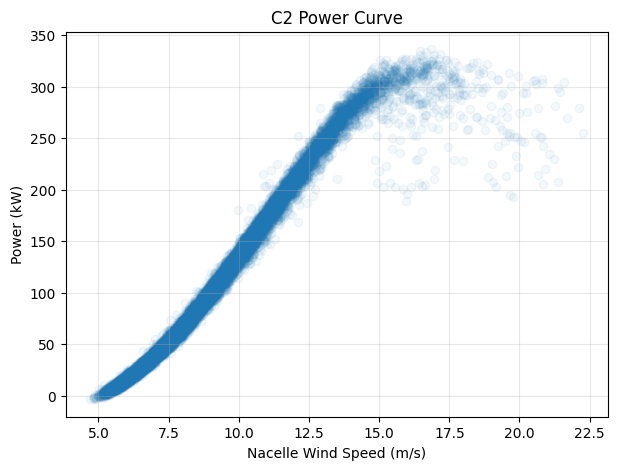


Training samples: 15011
Testing samples: 3753

C2 model performance:


,Model,MAE [kW],RMSE [kW]
0,Linear Regression,7.27,9.58
1,Random Forest,3.60,4.96
2,Gradient Boosting,3.54,4.83


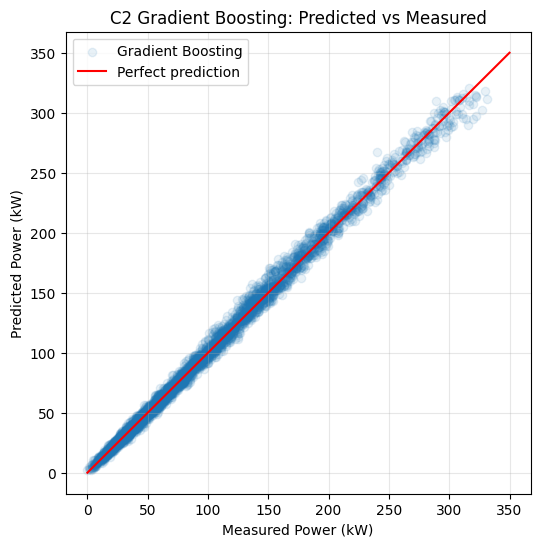

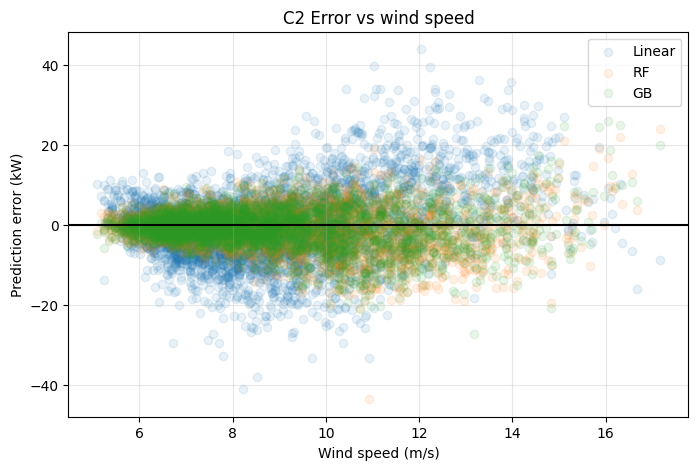

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# 1. Build dataframe for C2
# -----------------------------
df_c2 = pd.DataFrame({
    "power": ds["c2_pow"].values,
    "ws_nacelle": ds["c2_wsn"].values,
    "yaw_misalignment": ds["c2_ym"].values,
    "mast_ws1": ds["s31_1"].values,
    "mast_ws2": ds["s31_2"].values,
    "wind_dir1": ds["d31_1"].values,
    "wind_dir2": ds["d34_2"].values
})

# Derived features
df_c2["mast_ws"] = (df_c2["mast_ws1"] + df_c2["mast_ws2"]) / 2
df_c2["mast_dir"] = (df_c2["wind_dir1"] + df_c2["wind_dir2"]) / 2
df_c2["prev_power"] = df_c2["power"].shift(1)

# Circular wind direction encoding
df_c2["dir_sin"] = np.sin(np.deg2rad(df_c2["mast_dir"]))
df_c2["dir_cos"] = np.cos(np.deg2rad(df_c2["mast_dir"]))

# Keep only relevant columns
df_c2 = df_c2[[
    "power",
    "ws_nacelle",
    "yaw_misalignment",
    "mast_ws",
    "dir_sin",
    "dir_cos",
    "prev_power"
]]

# Drop missing values
print("Total rows before cleaning:", len(df_c2))
print("\nMissing values per column:")
print(df_c2.isna().sum())

df_c2 = df_c2.dropna()

print("\nRows after cleaning:", len(df_c2))

# -----------------------------
# 2. Sanity check power curve
# -----------------------------
plt.figure(figsize=(7, 5))
plt.scatter(df_c2["ws_nacelle"], df_c2["power"], alpha=0.05)
plt.xlabel("Nacelle Wind Speed (m/s)")
plt.ylabel("Power (kW)")
plt.title("C2 Power Curve")
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_c2_power_curve.png", dpi=300)
plt.show()

# -----------------------------
# 3. Feature matrix
# -----------------------------
features = [
    "ws_nacelle",
    "yaw_misalignment",
    "mast_ws",
    "dir_sin",
    "dir_cos",
    "prev_power"
]

X_c2 = df_c2[features]
y_c2 = df_c2["power"]

# Chronological split
split_index_c2 = int(len(df_c2) * 0.8)

X_train_c2 = X_c2.iloc[:split_index_c2]
X_test_c2  = X_c2.iloc[split_index_c2:]

y_train_c2 = y_c2.iloc[:split_index_c2]
y_test_c2  = y_c2.iloc[split_index_c2:]

print("\nTraining samples:", len(X_train_c2))
print("Testing samples:", len(X_test_c2))

# -----------------------------
# 4. Linear Regression
# -----------------------------
lin_model_c2 = LinearRegression()
lin_model_c2.fit(X_train_c2, y_train_c2)
y_pred_lin_c2 = lin_model_c2.predict(X_test_c2)

mae_lin_c2 = mean_absolute_error(y_test_c2, y_pred_lin_c2)
rmse_lin_c2 = np.sqrt(mean_squared_error(y_test_c2, y_pred_lin_c2))

# -----------------------------
# 5. Random Forest
# -----------------------------
rf_model_c2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_model_c2.fit(X_train_c2, y_train_c2)
y_pred_rf_c2 = rf_model_c2.predict(X_test_c2)

mae_rf_c2 = mean_absolute_error(y_test_c2, y_pred_rf_c2)
rmse_rf_c2 = np.sqrt(mean_squared_error(y_test_c2, y_pred_rf_c2))

# -----------------------------
# 6. Gradient Boosting
# -----------------------------
gb_model_c2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb_model_c2.fit(X_train_c2, y_train_c2)
y_pred_gb_c2 = gb_model_c2.predict(X_test_c2)

mae_gb_c2 = mean_absolute_error(y_test_c2, y_pred_gb_c2)
rmse_gb_c2 = np.sqrt(mean_squared_error(y_test_c2, y_pred_gb_c2))

# -----------------------------
# 7. Results table
# -----------------------------
results_c2 = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE [kW]": [mae_lin_c2, mae_rf_c2, mae_gb_c2],
    "RMSE [kW]": [rmse_lin_c2, rmse_rf_c2, rmse_gb_c2]
})

print("\nC2 model performance:")
display(results_c2.round(2))


# -----------------------------
# 8. Predicted vs measured plot
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test_c2, y_pred_gb_c2, alpha=0.1, label="Gradient Boosting")
plt.plot([0, 350], [0, 350], color="red", label="Perfect prediction")
plt.xlabel("Measured Power (kW)")
plt.ylabel("Predicted Power (kW)")
plt.title("C2 Gradient Boosting: Predicted vs Measured")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_c2_pred_vs_meas.png", dpi=300)
plt.show()

# -----------------------------
# 9. Error vs wind speed
# -----------------------------
errors_lin_c2 = y_test_c2 - y_pred_lin_c2
errors_rf_c2 = y_test_c2 - y_pred_rf_c2
errors_gb_c2 = y_test_c2 - y_pred_gb_c2

plt.figure(figsize=(8, 5))
plt.scatter(X_test_c2["ws_nacelle"], errors_lin_c2, alpha=0.1, label="Linear")
plt.scatter(X_test_c2["ws_nacelle"], errors_rf_c2, alpha=0.1, label="RF")
plt.scatter(X_test_c2["ws_nacelle"], errors_gb_c2, alpha=0.1, label="GB")
plt.axhline(0, color="black")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Prediction error (kW)")
plt.title("C2 Error vs wind speed")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_c2_error_vs_wind_speed.png", dpi=300)
plt.show()

In [79]:
print("Linear:", mae_lin_c2, rmse_lin_c2)
print("RF:", mae_rf_c2, rmse_rf_c2)
print("GB:", mae_gb_c2, rmse_gb_c2)

Linear: 7.266059196894214 9.580726630402536
RF: 3.599129096722624 4.955744290856044
GB: 3.5379316645888683 4.833095981176905


| Model  | A2 RMSE | C2 RMSE  |
| ------ | ------- | -------- |
| Linear | 15.40   | **9.58** |
| RF     | 18.73   | **4.96** |
| GB     | 17.57   | **4.83** |

**C2 wake is much more easier to predict than A2 wake**

Why this happens:
- A2
    - Exposed to full wind variability
    - Strong fluctuations
    - More chaotic signal
    - Harder for ML
- C2
    - Received reduced + smoothed wind
    - Less variability
    - More stable behavior
    - Easier for ML

**Final conclusion**

The machine learning models were applied to two turbines with different positions in the wind farm:

- A2 (upstream turbine)
- C2 (downstream, wake-affected turbine)

For turbine A2, the models achieved RMSE values between approximately 15–19 kW, with linear regression providing the most stable predictions.

For turbine C2, all models achieved significantly lower errors, with Gradient Boosting achieving the best performance (RMSE ≈ 4.8 kW).

Unexpectedly, the wake-affected turbine exhibited more predictable behavior than the upstream turbine.

This can be explained by the smoothing effect of wake interactions. While wake effects reduce the available wind energy, they also reduce variability in inflow conditions. As a result, the power output of downstream turbines becomes more stable and easier to predict using machine learning models.

This highlights an important distinction between physical performance and predictability:
- Upstream turbines produce more power but exhibit higher variability
- Downstream turbines produce less power but are more predictable

The results demonstrate that machine learning performance depends not only on model complexity, but also on the physical characteristics of the system being modeled.

# 3. Prediction performance along wake chain

In [80]:
def run_pipeline(turbine):

    df = pd.DataFrame({
        "power": ds[f"{turbine}_pow"].values,
        "ws_nacelle": ds[f"{turbine}_wsn"].values,
        "yaw_misalignment": ds[f"{turbine}_ym"].values,
        "mast_ws1": ds["s31_1"].values,
        "mast_ws2": ds["s31_2"].values,
        "wind_dir1": ds["d31_1"].values,
        "wind_dir2": ds["d34_2"].values
    })

    # Feature engineering
    df["mast_ws"] = (df["mast_ws1"] + df["mast_ws2"]) / 2
    df["mast_dir"] = (df["wind_dir1"] + df["wind_dir2"]) / 2
    df["prev_power"] = df["power"].shift(1)

    df["dir_sin"] = np.sin(np.deg2rad(df["mast_dir"]))
    df["dir_cos"] = np.cos(np.deg2rad(df["mast_dir"]))

    df = df[[
        "power",
        "ws_nacelle",
        "yaw_misalignment",
        "mast_ws",
        "dir_sin",
        "dir_cos",
        "prev_power"
    ]].dropna()

    # Features
    features = [
        "ws_nacelle",
        "yaw_misalignment",
        "mast_ws",
        "dir_sin",
        "dir_cos",
        "prev_power"
    ]

    X = df[features]
    y = df["power"]

    split = int(len(df) * 0.8)

    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # Models
    lin = LinearRegression().fit(X_train, y_train)
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
    gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42).fit(X_train, y_train)

    # Predictions
    preds = {
        "Linear": lin.predict(X_test),
        "RF": rf.predict(X_test),
        "GB": gb.predict(X_test)
    }

    # Metrics
    results = {}

    for name, y_pred in preds.items():
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        results[name] = (mae, rmse)

    return results

In [81]:
# ----------------------
# Run for multiple turbines
# ----------------------

turbines = ['c2', 'd2', 'e2', 'f2']
results_all = {}

for t in turbines:
    results_all[t.upper()] = run_pipeline(t)


# --------------------------
# Build comparison table
# --------------------------

rows = []
for turb, models in results_all.items():
    for model, (mae, rmse) in models.items():
        rows.append({
            'Turbine': turb,
            'Model': model,
            'MAE': mae,
            'RMSE': rmse
        })

df_results = pd.DataFrame(rows)
df_results.sort_values(['Turbine', 'RMSE'])

,Turbine,Model,MAE,RMSE
2,C2,GB,3.537932,4.833096
1,C2,RF,3.599129,4.955744
0,C2,Linear,7.266059,9.580727
5,D2,GB,2.954356,4.208417
4,D2,RF,2.978971,4.244379
3,D2,Linear,7.541983,10.180014
7,E2,RF,3.420694,4.718680
8,E2,GB,3.410960,4.741579
6,E2,Linear,6.917835,9.355971
10,F2,RF,3.129128,4.362556


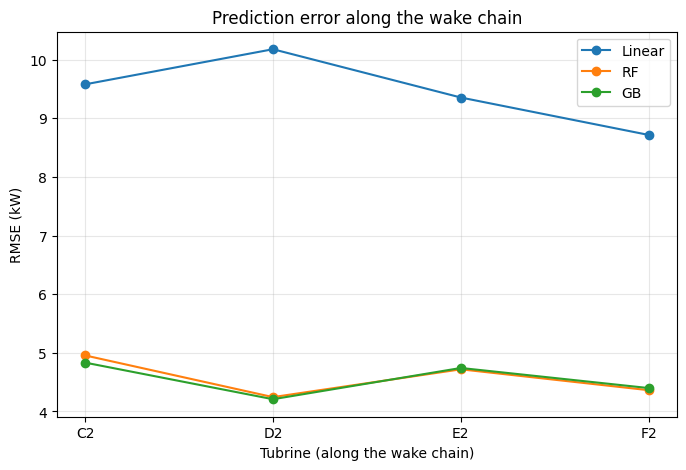

In [82]:


# --------------------------------------
# Plot RMSE vs turbine position
# --------------------------------------

plt.figure(figsize=(8,5))
for model in ['Linear', 'RF', 'GB']:
    subset = df_results[df_results['Model'] == model]
    plt.plot(subset['Turbine'], subset['RMSE'], marker='o', label=model)

plt.xlabel('Tubrine (along the wake chain)')
plt.ylabel('RMSE (kW)')
plt.title('Prediction error along the wake chain')

plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_prediction_error_wake_chain.png", dpi=300)
plt.show()



The machine learning pipeline was applied to multiple turbines along a wake chain (C2 → D2 → E2 → F2).

Results show that prediction error does not vary monotonically with turbine position.

Instead, the lowest prediction error is observed at turbine D2, which is located in the middle of the wake chain.

This suggests that turbines operating in stable wake conditions are easier to model than both upstream turbines and those experiencing complex multi-wake interactions.

- C2 (first wake interaction) exhibits slightly higher error
- D2 (stable wake region) shows lowest error
- E2 and F2 (multiple wake interactions) show slightly increased error

Tree-based models (Random Forest and Gradient Boosting) consistently outperform linear regression across all turbines, achieving RMSE values around 4–5 kW.

These results highlight that predictability in wind turbine power is influenced not only by wind conditions but also by the spatial structure of wake interactions within the wind farm.

# 4. Full wind farm model


After testing the machine learning pipeline on selected turbines along a wake chain, the analysis is extended to the full wind farm.

The objective is to evaluate how model performance varies spatially across the farm and identify which turbines are easier or harder to predict.

The same feature engineering and model settings are used for all turbines to ensure fair comparison.

- Goal is it analyze RMSE for all wind turbines
- Map errors spatially or histogram of RMSE across all wind turbines

Plan:
- Run the same ML pipeline for all turbines with power
- Compare model performance
- Indetify which turbines are easiest/hardest to predict
- Make spatial heatmap for RMSE

It will be divided into 3 parts:
- Part 1
    - Run pipeline for all valid turbines
- Part 2
    - Create results table and summary plots
- Part 3
    - Map RMSE onto turbine layout

**Important notice: Turbines without power need to be excluded**


## Core function

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------
# 1. List valid turbines
# ---------------------------
rows =  ['a', 'b', 'c', 'd', 'e', 'f']
cols = range(1,8)

all_turbines = [f'{r}{c}' for r in rows for c in cols]
invalid_turbines = ['a1', 'f6'] # Missing power channels
valid_turbines = [t for t in all_turbines if t not in invalid_turbines]

print('Number of valid turbines:', len(valid_turbines))
print(valid_turbines)

# --------------------------------
# 2. Reusable pipeline
# --------------------------------
def run_pipeline(turbine):
    df = pd.DataFrame({
        "power": ds[f"{turbine}_pow"].values,
        "ws_nacelle": ds[f"{turbine}_wsn"].values,
        "yaw_misalignment": ds[f"{turbine}_ym"].values,
        "mast_ws1": ds["s31_1"].values,
        "mast_ws2": ds["s31_2"].values,
        "wind_dir1": ds["d31_1"].values,
        "wind_dir2": ds["d34_2"].values
    })

    # feature engineering
    df["mast_ws"] = (df["mast_ws1"] + df["mast_ws2"]) / 2
    df["mast_dir"] = (df["wind_dir1"] + df["wind_dir2"]) / 2
    df["prev_power"] = df["power"].shift(1)

    # circular encoding of wind direction
    df["dir_sin"] = np.sin(np.deg2rad(df["mast_dir"]))
    df["dir_cos"] = np.cos(np.deg2rad(df["mast_dir"]))

    df = df[[
        "power",
        "ws_nacelle",
        "yaw_misalignment",
        "mast_ws",
        "dir_sin",
        "dir_cos",
        "prev_power"
    ]].dropna()

    # skip turbine if too few samples remain
    if len(df) < 1000:
        return None

    features = [
        "ws_nacelle",
        "yaw_misalignment",
        "mast_ws",
        "dir_sin",
        "dir_cos",
        "prev_power"
    ]

    X = df[features]
    y = df["power"]

    split = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    # models
    lin = LinearRegression()
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    gb = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    models = {
        "Linear": lin,
        "RF": rf,
        "GB": gb
    }

    rows_out = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        rows_out.append({
            "Turbine": turbine.upper(),
            "Model": model_name,
            "Samples": len(df),
            "Train_samples": len(X_train),
            "Test_samples": len(X_test),
            "MAE": mae,
            "RMSE": rmse
        })

    return rows_out

# ----------------------------------
# 3. Run for all turbines 
# ----------------------------------
all_results = []

for turbine in valid_turbines:
    result = run_pipeline(turbine)
    if result is not None:
        all_results.extend(result)

df_farm_results = pd.DataFrame(all_results)

print('Finished turbines:', df_farm_results['Turbine'].nunique())
df_farm_results.head()

Number of valid turbines: 40
['a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'f1', 'f2', 'f3', 'f4', 'f5', 'f7']
Finished turbines: 40


,Turbine,Model,Samples,Train_samples,Test_samples,MAE,RMSE
0,A2,Linear,18206,14564,3642,9.880502,15.403978
1,A2,RF,18206,14564,3642,7.770990,18.728832
2,A2,GB,18206,14564,3642,7.484530,17.567438
3,A3,Linear,18832,15065,3767,8.256890,11.131943
4,A3,RF,18832,15065,3767,3.111632,4.421230


## Summary Table

In [84]:
# Sort all results
df_farm_results = df_farm_results.sort_values(['Turbine','RMSE']).reset_index(drop=True)

# Best model per turbine
best_model_per_turbine = (
    df_farm_results.sort_values(['Turbine', 'RMSE'])
    .groupby('Turbine', as_index=False)
    .first()
)

print('Best model per turbine:')
display(best_model_per_turbine.head(10))

# Mean performance by model accross farm
model_summary = (
    df_farm_results.groupby('Model')[['MAE', 'RMSE']]
    .mean()
    .sort_values('RMSE')
)

print('Average performance across wind farm:')
display(model_summary.round(2))

Best model per turbine:


,Turbine,Model,Samples,Train_samples,Test_samples,MAE,RMSE
0,A2,Linear,18206,14564,3642,9.880502,15.403978
1,A3,RF,18832,15065,3767,3.111632,4.421230
2,A4,GB,18036,14428,3608,4.835413,10.317135
3,A5,GB,18999,15199,3800,4.596819,5.868226
4,A6,GB,19020,15216,3804,3.433211,4.788102
5,A7,RF,19002,15201,3801,3.530053,4.965374
6,B1,GB,18916,15132,3784,3.731547,5.248973
7,B2,GB,18965,15172,3793,3.830489,5.659873
8,B3,GB,19088,15270,3818,3.187596,4.522342
9,B4,GB,18940,15152,3788,3.165813,4.414016


Average performance across wind farm:


,MAE,RMSE
Model,,
GB,4.47,7.25
RF,4.58,7.57
Linear,8.75,12.36


## Compare models across all wind turbines

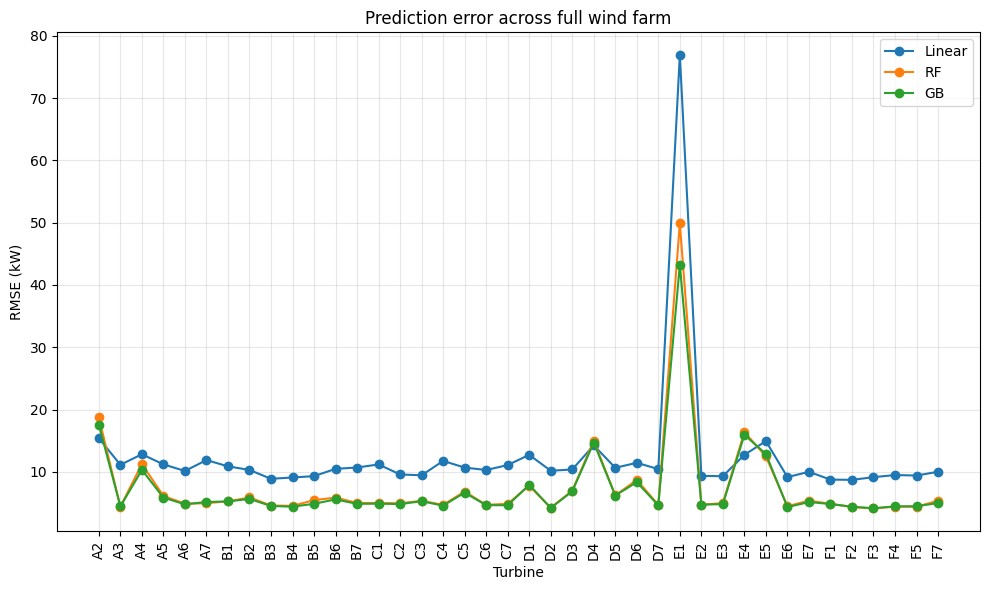

In [85]:
plt.figure(figsize=(10,6))

for model in ['Linear', 'RF', 'GB']:
    subset = df_farm_results[df_farm_results['Model'] == model].sort_values('Turbine')
    plt.plot(subset['Turbine'], subset['RMSE'], marker='o', label=model)

plt.xticks(rotation=90)
plt.xlabel('Turbine')
plt.ylabel('RMSE (kW)')
plt.title('Prediction error across full wind farm')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/sprint4_pred_error_full_wf.png", dpi=300)
plt.show()

## Easiest to hardest wind turbines


In [86]:
print('10 easiest turbines to predict (Best RMSE):')
display(best_model_per_turbine.sort_values('RMSE').head(10).round(2))

print('10 hardest turbines to predict (Worst RMSE):')
display(best_model_per_turbine.sort_values('RMSE',ascending=False).head(10).round(2))

10 easiest turbines to predict (Best RMSE):


,Turbine,Model,Samples,Train_samples,Test_samples,MAE,RMSE
36,F3,RF,19075,15260,3815,3.07,4.13
21,D2,GB,18893,15114,3779,2.95,4.21
32,E6,GB,18908,15126,3782,3.08,4.35
35,F2,RF,18733,14986,3747,3.13,4.36
38,F5,RF,18831,15064,3767,3.12,4.39
9,B4,GB,18940,15152,3788,3.17,4.41
1,A3,RF,18832,15065,3767,3.11,4.42
37,F4,RF,19035,15228,3807,3.24,4.43
8,B3,GB,19088,15270,3818,3.19,4.52
16,C4,GB,17655,14124,3531,3.30,4.58


10 hardest turbines to predict (Worst RMSE):


,Turbine,Model,Samples,Train_samples,Test_samples,MAE,RMSE
27,E1,GB,18843,15074,3769,17.89,43.22
0,A2,Linear,18206,14564,3642,9.88,15.40
23,D4,Linear,18226,14580,3646,10.68,14.26
30,E4,Linear,18697,14957,3740,9.33,12.74
31,E5,RF,18541,14832,3709,7.63,12.47
2,A4,GB,18036,14428,3608,4.84,10.32
25,D6,GB,18506,14804,3702,4.80,8.35
20,D1,RF,18835,15068,3767,4.70,7.77
22,D3,GB,18881,15104,3777,4.17,6.88
17,C5,GB,18823,15058,3765,4.28,6.66


## Prepare layout coordinates for heatmap

Since your farm layout is regular, we can create plotting coordinates directly from turbine names.

Rows:

A to F

Columns:

1 to 7

We’ll assign:

x = column number

y = row index

In [87]:
row_to_y = {
    "A": 6,
    "B": 5,
    "C": 4,
    "D": 3,
    "E": 2,
    "F": 1
}

heatmap_df = best_model_per_turbine.copy()
heatmap_df["Row"] = heatmap_df["Turbine"].str[0]
heatmap_df["Col"] = heatmap_df["Turbine"].str[1:].astype(int)
heatmap_df["x"] = heatmap_df["Col"]
heatmap_df["y"] = heatmap_df["Row"].map(row_to_y)

heatmap_df.head()

,Turbine,Model,Samples,Train_samples,Test_samples,MAE,RMSE,Row,Col,x,y
0,A2,Linear,18206,14564,3642,9.880502,15.403978,A,2,2,6
1,A3,RF,18832,15065,3767,3.111632,4.421230,A,3,3,6
2,A4,GB,18036,14428,3608,4.835413,10.317135,A,4,4,6
3,A5,GB,18999,15199,3800,4.596819,5.868226,A,5,5,6
4,A6,GB,19020,15216,3804,3.433211,4.788102,A,6,6,6


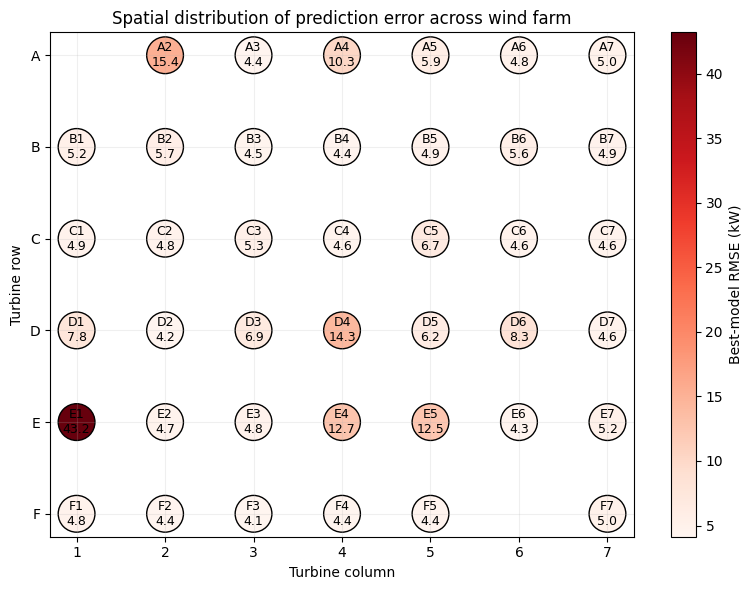

In [88]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    heatmap_df["x"],
    heatmap_df["y"],
    c=heatmap_df["RMSE"],
    s=700,
    cmap="Reds",
    edgecolor="black"
)

# turbine labels
for _, row in heatmap_df.iterrows():
    plt.text(
        row["x"],
        row["y"],
        f"{row['Turbine']}\n{row['RMSE']:.1f}",
        ha="center",
        va="center",
        fontsize=9
    )

plt.colorbar(sc, label="Best-model RMSE (kW)")
plt.xticks(range(1, 8))
plt.yticks([1, 2, 3, 4, 5, 6], ["F", "E", "D", "C", "B", "A"])
plt.xlabel("Turbine column")
plt.ylabel("Turbine row")
plt.title("Spatial distribution of prediction error across wind farm")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig("../figures/sprint4_distribution_of_error_full_wf.png", dpi=300)
plt.show()

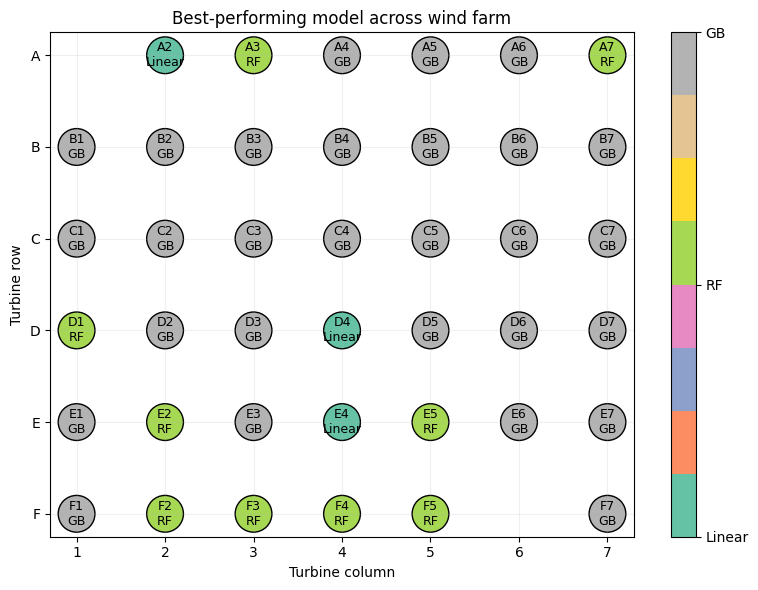

In [89]:
model_to_num = {"Linear": 0, "RF": 1, "GB": 2}
num_to_model = {0: "Linear", 1: "RF", 2: "GB"}

heatmap_df["Model_num"] = heatmap_df["Model"].map(model_to_num)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    heatmap_df["x"],
    heatmap_df["y"],
    c=heatmap_df["Model_num"],
    s=700,
    cmap="Set2",
    edgecolor="black"
)

for _, row in heatmap_df.iterrows():
    plt.text(
        row["x"],
        row["y"],
        f"{row['Turbine']}\n{row['Model']}",
        ha="center",
        va="center",
        fontsize=9
    )

cbar = plt.colorbar(sc, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["Linear", "RF", "GB"])

plt.xticks(range(1, 8))
plt.yticks([1, 2, 3, 4, 5, 6], ["F", "E", "D", "C", "B", "A"])
plt.xlabel("Turbine column")
plt.ylabel("Turbine row")
plt.title("Best-performing model across wind farm")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig("../figures/sprint4_best_models_full_wf.png", dpi=300)
plt.show()

## Full wind farm conclusion

The machine learning pipeline was applied to all turbines with available power signals in the wind farm.

For each turbine, three models were evaluated:
- Linear Regression
- Random Forest
- Gradient Boosting

The results show how prediction error varies spatially across the farm.

The spatial RMSE map helps identify turbines that are easier or harder to model, which may be related to turbine position, wake exposure, and inflow variability.

This farm-wide analysis extends the earlier single-turbine and wake-chain studies by evaluating whether local wake effects translate into broader spatial patterns of predictability.

## Final remarks

The machine learning pipeline was applied to all turbines in the wind farm to evaluate spatial variations in prediction performance.

Results show that prediction error is not uniform across the farm, but strongly dependent on turbine location.

Most turbines achieved low prediction errors (RMSE ≈ 4–6 kW) using tree-based models, indicating that turbine power can be accurately predicted when inflow conditions are stable.

However, several turbines exhibited significantly higher prediction errors, most notably turbine E1 (RMSE > 40 kW). These turbines are likely affected by complex flow conditions, such as variable wake interactions or edge effects.

The spatial distribution of prediction error reveals that turbines located in stable wake regions tend to be easier to predict, while turbines experiencing either highly variable inflow or multiple wake interactions are more challenging.

Gradient Boosting was the best-performing model for the majority of turbines, confirming the importance of nonlinear modeling. However, linear regression provided more robust predictions in certain high-variability cases.

These results demonstrate that machine learning performance in wind farm applications is strongly linked to physical flow conditions and turbine positioning.

# 5. Tuning of model based on the worst E1 turbine

The machine learning pipeline was applied to all turbines in the wind farm to evaluate spatial variations in prediction performance.

Results show that prediction error is not uniform across the farm, but strongly dependent on turbine location.

Most turbines achieved low prediction errors (RMSE ≈ 4–6 kW) using tree-based models, indicating that turbine power can be accurately predicted when inflow conditions are stable.

However, several turbines exhibited significantly higher prediction errors, most notably turbine E1 (RMSE > 40 kW). These turbines are likely affected by complex flow conditions, such as variable wake interactions or edge effects.

The spatial distribution of prediction error reveals that turbines located in stable wake regions tend to be easier to predict, while turbines experiencing either highly variable inflow or multiple wake interactions are more challenging.

Gradient Boosting was the best-performing model for the majority of turbines, confirming the importance of nonlinear modeling. However, linear regression provided more robust predictions in certain high-variability cases.

These results demonstrate that machine learning performance in wind farm applications is strongly linked to physical flow conditions and turbine positioning.


In [90]:
# --------------------------------------
# E1 dataset preparation
# --------------------------------------

df_e1 = pd.DataFrame({
    'power': ds['e1_pow'].values,
    'ws_nacelle': ds['e1_wsn'].values,
    'yaw_misalignment': ds['e1_ym'].values,
    'mast_ws1': ds['s31_1'].values,
    'mast_ws2': ds['s31_2'].values,
    'wind_dir1': ds['d31_1'].values,
    'wind_dir2': ds['d34_2'].values
})

df_e1['mast_ws'] = (df_e1['mast_ws1'] + df_e1['mast_ws2']) / 2
df_e1["mast_dir"] = (df_e1["wind_dir1"] + df_e1["wind_dir2"]) / 2
df_e1["prev_power"] = df_e1["power"].shift(1)

df_e1["dir_sin"] = np.sin(np.deg2rad(df_e1["mast_dir"]))
df_e1["dir_cos"] = np.cos(np.deg2rad(df_e1["mast_dir"]))

df_e1 = df_e1[[
    "power",
    "ws_nacelle",
    "yaw_misalignment",
    "mast_ws",
    "dir_sin",
    "dir_cos",
    "prev_power"
]].dropna()

features = [
    'ws_nacelle',
    'yaw_misalignment',
    'mast_ws',
    'dir_sin',
    'dir_cos',
    'prev_power'
]

X_e1 = df_e1[features]
y_e1 = df_e1['power']

split_e1 = int(len(df_e1) * 0.8)

X_train_e1 = X_e1.iloc[:split_e1]
X_test_e1 = X_e1.iloc[split_e1:]

y_train_e1 = y_e1.iloc[:split_e1]
y_test_e1 = y_e1.iloc[split_e1:]

print('Training samples:', len(X_train_e1))
print('Testing samples:', len(X_test_e1))

Training samples: 15074
Testing samples: 3769


**Model run**

In [91]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Baseline model
gb_e1_base = GradientBoostingRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth = 3,
    random_state = 42
)

gb_e1_base.fit(X_train_e1, y_train_e1)
y_pred_e1_base = gb_e1_base.predict(X_test_e1)

mae_e1_base = mean_absolute_error(y_test_e1, y_pred_e1_base)
rmse_e1_base = np.sqrt(mean_squared_error(y_test_e1, y_pred_e1_base))

print('E1 baseline Gradient Boosting')
print(f'MAE: {mae_e1_base:.2f} kW')
print(f'RMSE: {rmse_e1_base:.2F} kW')

E1 baseline Gradient Boosting
MAE: 17.89 kW
RMSE: 43.22 kW


**Small hyperparameter grid**

In [92]:
from itertools import product

param_grid = {
    'n_estimators': [100,200,300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]
}
results_tuning = []

for n_estimators, learning_rate, max_depth in product(
    param_grid['n_estimators'],
    param_grid['learning_rate'],
    param_grid['max_depth']
):
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )

    model.fit(X_train_e1, y_train_e1)
    y_pred = model.predict(X_test_e1)

    mae = mean_absolute_error(y_test_e1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_e1, y_pred))

    results_tuning.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'MAE': mae,
        'RMSE': rmse
    })

tuning_df = pd.DataFrame(results_tuning).sort_values('RMSE').reset_index(drop=True)
display(tuning_df.head(10).round(3))

,n_estimators,learning_rate,max_depth,MAE,RMSE
0,100,0.03,2,17.281,40.924
1,100,0.05,2,17.433,42.261
2,200,0.03,2,17.606,42.496
3,100,0.03,3,17.913,42.645
4,300,0.03,2,17.765,42.716
5,200,0.05,2,17.848,42.844
6,100,0.05,3,17.739,43.009
7,200,0.03,3,17.769,43.143
8,300,0.05,2,17.960,43.163
9,200,0.05,3,17.886,43.222


**Train best model**

In [93]:
best_params = tuning_df.iloc[0]
print('Best params found:')
print(best_params)

gb_e1_tuned = GradientBoostingRegressor(
    n_estimators=int(best_params["n_estimators"]),
    learning_rate=float(best_params["learning_rate"]),
    max_depth=int(best_params["max_depth"]),
    random_state=42
)

gb_e1_tuned.fit(X_train_e1, y_train_e1)
y_pred_e1_tuned = gb_e1_tuned.predict(X_test_e1)

mae_e1_tuned = mean_absolute_error(y_test_e1, y_pred_e1_tuned)
rmse_e1_tuned = np.sqrt(mean_squared_error(y_test_e1, y_pred_e1_tuned))

print("\nE1 tuned Gradient Boosting")
print(f"MAE  : {mae_e1_tuned:.2f} kW")
print(f"RMSE : {rmse_e1_tuned:.2f} kW")

Best params found:
n_estimators     100.000000
learning_rate      0.030000
max_depth          2.000000
MAE               17.281186
RMSE              40.923541
Name: 0, dtype: float64

E1 tuned Gradient Boosting
MAE  : 17.28 kW
RMSE : 40.92 kW


**Compare baseline vs tuned**

In [94]:
comparison_e1 = pd.DataFrame({
    "Model version": ["Baseline GB", "Tuned GB"],
    "MAE [kW]": [mae_e1_base, mae_e1_tuned],
    "RMSE [kW]": [rmse_e1_base, rmse_e1_tuned]
})

display(comparison_e1.round(3))

rmse_improvement = 100 * (rmse_e1_base - rmse_e1_tuned) / rmse_e1_base
mae_improvement = 100 * (mae_e1_base - mae_e1_tuned) / mae_e1_base

print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"MAE improvement : {mae_improvement:.2f}%")

,Model version,MAE [kW],RMSE [kW]
0,Baseline GB,17.886,43.222
1,Tuned GB,17.281,40.924


RMSE improvement: 5.32%
MAE improvement : 3.38%


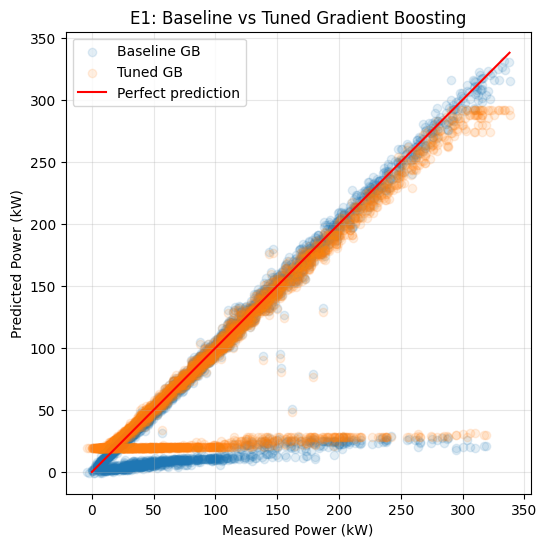

In [95]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_e1, y_pred_e1_base, alpha=0.12, label="Baseline GB")
plt.scatter(y_test_e1, y_pred_e1_tuned, alpha=0.12, label="Tuned GB")

plt.plot([0, max(y_test_e1)], [0, max(y_test_e1)], color="red", label="Perfect prediction")

plt.xlabel("Measured Power (kW)")
plt.ylabel("Predicted Power (kW)")
plt.title("E1: Baseline vs Tuned Gradient Boosting")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_e1_baseline_vs_tuned_gb.png", dpi=300)
plt.show()

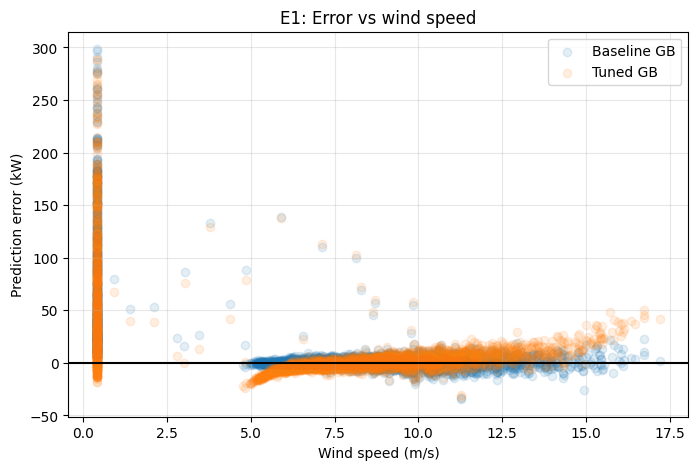

In [96]:
errors_e1_base = y_test_e1 - y_pred_e1_base
errors_e1_tuned = y_test_e1 - y_pred_e1_tuned

plt.figure(figsize=(8,5))

plt.scatter(X_test_e1["ws_nacelle"], errors_e1_base, alpha=0.12, label="Baseline GB")
plt.scatter(X_test_e1["ws_nacelle"], errors_e1_tuned, alpha=0.12, label="Tuned GB")

plt.axhline(0, color="black")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Prediction error (kW)")
plt.title("E1: Error vs wind speed")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/sprint4_e1_error_vs_wind_speed.png", dpi=300)
plt.show()

## Targeted model tuning for the most difficult turbine

Turbine E1 was identified as the most difficult turbine to predict in the wind farm, with significantly higher prediction error compared to all other turbines.

A targeted hyperparameter tuning of the Gradient Boosting model was performed to assess whether the high prediction error is primarily due to suboptimal model configuration or underlying data complexity.

The tuned model achieved a modest improvement:
- RMSE reduced from 43.2 kW to 40.9 kW (~5.3%)
- MAE reduced by ~3.4%

The best-performing configuration used a simpler model structure (lower tree depth and lower learning rate), indicating that reduced model complexity improves robustness for this turbine.

However, the overall improvement remains limited, suggesting that the high prediction error for E1 is not primarily due to model choice, but rather due to turbine-specific factors such as:
- highly variable inflow conditions
- complex wake interactions
- potential data quality issues

This result highlights that model tuning alone cannot fully compensate for challenging physical conditions, and that prediction performance is fundamentally constrained by the underlying system dynamics.

# 6. Conclusions

This project investigated the use of machine learning models to predict wind turbine power output based on SCADA data, with a particular focus on understanding how prediction performance is influenced by wake effects and turbine position within a wind farm.

### Model performance

Three models were evaluated: Linear Regression, Random Forest, and Gradient Boosting.
Tree-based models consistently outperformed the linear baseline, achieving typical RMSE values in the range of 4–6 kW for most turbines. This confirms that turbine power generation is governed by nonlinear relationships that cannot be fully captured by simple linear models.

Gradient Boosting provided the best overall performance across the wind farm, while Linear Regression served as a useful and interpretable baseline.

### Wake-aware prediction behavior

Analysis along a turbine row (C2 → D2 → E2 → F2) showed that prediction accuracy does not vary monotonically with downstream position.
The lowest prediction error was observed for turbines located in stable wake regions, while turbines experiencing either initial wake interaction or multiple overlapping wakes exhibited higher error.

This demonstrates that wake effects do not uniformly degrade prediction performance. Instead, **predictability depends on the stability of the inflow conditions rather than the presence of a wake alone**.

### Spatial variability across the wind farm

Extending the analysis to the full wind farm revealed strong spatial patterns in prediction error.
Most turbines showed low and consistent error levels, while a small number of turbines exhibited significantly higher prediction errors.

These differences are likely linked to turbine-specific operating conditions, including:

* edge effects
* varying wake exposure
* local turbulence intensity
* possible data quality issues

The spatial RMSE map highlights that prediction difficulty is not random, but strongly related to turbine position within the farm.

### Outlier behavior and model robustness

Turbine E1 was identified as a clear outlier, with prediction errors significantly higher than the rest of the farm.
Targeted hyperparameter tuning of the Gradient Boosting model resulted in only modest improvements (~5% reduction in RMSE), indicating that model configuration is not the primary limitation.

The best-performing tuned model used reduced complexity, suggesting that simpler models are more robust in highly variable or noisy operating conditions.

This highlights an important insight:

**Model tuning alone cannot compensate for complex physical behavior or missing explanatory variables.**

### Overall findings

The results of this project demonstrate that:

* Machine learning models can accurately predict wind turbine power under stable conditions
* Prediction performance is strongly influenced by wake dynamics and turbine location
* Nonlinear models are essential for capturing turbine behavior
* Model complexity should be adapted to the variability of the operating regime
* Physical understanding of the system is crucial for interpreting model performance

### Final remark

This study shows that combining SCADA data with machine learning provides valuable insights into both turbine performance and wind farm aerodynamics. However, it also emphasizes that data-driven models remain fundamentally constrained by the underlying physical processes governing the system.
